# Clasical ML model selection - All features

Just like in 06_classification_baseline.ipynb, I'm going to use the following models:
- Logistic Regression
- Random Forest
- XGBoost
- Support Vector Machines

Run with all features...

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)

import xgboost as xgb

import joblib
import json
from datetime import datetime
import os

import core.constants as c
from core.processing import ResultsModel, ResultModel
from core.utils import extract_subject_id
from core.evaluation import model_test_summary, pick_threshold
from core.model_selection import split_train_test_set
from core.evaluation import SklearnAPIPredictor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
SAVE_MODEL = False
MODEL_NAME = "baseline_strict_out_all_data_40"

In [3]:
X_train_all = pd.read_csv(c.RICKD_MODEL_1_X_TRAIN_FILE_40_FEATURES_2, index_col=0)
y_train_all = pd.read_csv(c.RICKD_MODEL_1_Y_TRAIN_FILE_2, index_col=0)

X_train, X_val, y_train, y_val = split_train_test_set(
    X_train_all, y_train_all, test_size=0.2, random_state=RANDOM_STATE, groups=extract_subject_id(X_train_all.index.to_series())
)

print("="*30)
print("Train")
print("="*30)
print(f"X Dataset shape: {X_train.shape}")
print(f"X Columns: {list(X_train.columns)}")
display(X_train.head())

print(f"Y Dataset shape: {y_train.shape}")
print(f"Y Columns: {list(y_train.columns)}")
display(y_train.head())

# Class imbalance
print(f"Class distribution: {y_train['is_injured'].value_counts()}")
print(f"Class distribution: {y_train['is_injured'].value_counts(normalize=True)}")


print("\n" + "="*30)
print("Validation")
print("="*30)
print(f"X Dataset shape: {X_val.shape}")
print(f"X Columns: {list(X_val.columns)}")
display(X_val.head())

print(f"Y Dataset shape: {y_val.shape}")
print(f"Y Columns: {list(y_val.columns)}")
display(y_val.head())

# Class imbalance
print(f"Class distribution: {y_val['is_injured'].value_counts()}")
print(f"Class distribution: {y_val['is_injured'].value_counts(normalize=True)}")


Train
X Dataset shape: (1142, 40)
X Columns: ['age', 'weight', 'dom_leg_ankle_df_peak_angle', 'dom_leg_ankle_eve_peak_angle', 'dom_leg_diff_ankle_eve_peak_angle', 'dom_leg_ankle_eve_peak_vel', 'dom_leg_diff_ankle_eve_percent_stance', 'dom_leg_ankle_rot_excursion', 'dom_leg_ankle_rot_peak_vel', 'dom_leg_diff_ankle_rot_peak_vel', 'dom_leg_foot_ang_at_hs', 'dom_leg_diff_foot_ang_at_hs', 'dom_leg_diff_hip_abd_peak_vel', 'dom_leg_hip_add_excursion', 'dom_leg_diff_hip_add_peak_angle', 'dom_leg_diff_hip_add_peak_vel', 'dom_leg_hip_ext_peak_angle', 'dom_leg_diff_hip_ext_peak_angle', 'dom_leg_hip_rot_excursion', 'dom_leg_hip_rot_peak_vel', 'dom_leg_knee_add_peak_angle', 'dom_leg_diff_knee_add_peak_vel', 'dom_leg_knee_flex_peak_angle', 'dom_leg_diff_knee_flex_peak_angle', 'dom_leg_knee_rot_excursion', 'dom_leg_knee_rot_peak_angle', 'dom_leg_diff_knee_rot_peak_vel', 'dom_leg_mhw_exc_from_to', 'dom_leg_diff_mhw_exc_from_to', 'dom_leg_pelvic_drop_peak_vel', 'dom_leg_diff_pelvic_drop_peak_vel', 'dom

,age,weight,dom_leg_ankle_df_peak_angle,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,dom_leg_diff_ankle_eve_percent_stance,dom_leg_ankle_rot_excursion,dom_leg_ankle_rot_peak_vel,dom_leg_diff_ankle_rot_peak_vel,...,dom_leg_diff_pelvic_drop_peak_vel,dom_leg_pelvis_drop_excursion,dom_leg_pelvis_peak_drop_angle,dom_leg_diff_pelvis_peak_drop_angle,dom_leg_stance_time,dom_leg_step_width,dom_leg_stride_length,dom_leg_stride_rate,dom_leg_supination_timing,dom_leg_swing_time
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,0.716796,-0.634605,1.018751,1.485201,0.489915,1.350380,-0.210953,-0.787213,0.487663,0.930900,...,-0.987459,1.960504,1.668759,1.867601,0.740463,2.003936,-0.288262,-0.851780,0.567631,0.185710
100002_20110601T140505,-0.099721,0.029859,1.087823,-0.951915,-0.165420,0.786429,0.575808,1.309684,1.406198,0.365431,...,0.257177,1.563453,1.451348,1.597808,-0.171642,-0.796692,0.063442,-0.321937,-0.343351,0.439287
100003_20110601T095930,1.043402,1.244226,1.311845,-0.657482,-0.043043,-0.070744,-1.896870,-0.112823,0.676814,-1.045915,...,-0.463421,-0.309219,-0.415110,-0.051693,0.588446,1.194771,0.837726,-0.851780,-0.950672,0.439287
100006_20110209T104505,0.226886,0.824162,0.451787,0.830074,1.841848,-0.252981,0.351019,0.542946,-0.437143,-0.197829,...,2.193853,-0.408676,-0.374693,-0.996001,-0.779712,1.008673,0.132266,0.728535,-1.051892,-0.067866
100007_20110209T135403,-0.263025,1.053288,0.436480,1.158034,0.213426,0.557343,0.463413,-1.790726,-0.435175,0.367266,...,-1.177927,-0.825046,-0.028485,-0.148850,0.892481,1.931033,-1.223324,0.363477,0.061530,-1.208959


Y Dataset shape: (1142, 1)
Y Columns: ['is_injured']


,is_injured
id,
100001_20110531T161051,True
100002_20110601T140505,True
100003_20110601T095930,True
100006_20110209T104505,True
100007_20110209T135403,True


Class distribution: is_injured
True     734
False    408
Name: count, dtype: int64
Class distribution: is_injured
True     0.642732
False    0.357268
Name: proportion, dtype: float64

Validation
X Dataset shape: (304, 40)
X Columns: ['age', 'weight', 'dom_leg_ankle_df_peak_angle', 'dom_leg_ankle_eve_peak_angle', 'dom_leg_diff_ankle_eve_peak_angle', 'dom_leg_ankle_eve_peak_vel', 'dom_leg_diff_ankle_eve_percent_stance', 'dom_leg_ankle_rot_excursion', 'dom_leg_ankle_rot_peak_vel', 'dom_leg_diff_ankle_rot_peak_vel', 'dom_leg_foot_ang_at_hs', 'dom_leg_diff_foot_ang_at_hs', 'dom_leg_diff_hip_abd_peak_vel', 'dom_leg_hip_add_excursion', 'dom_leg_diff_hip_add_peak_angle', 'dom_leg_diff_hip_add_peak_vel', 'dom_leg_hip_ext_peak_angle', 'dom_leg_diff_hip_ext_peak_angle', 'dom_leg_hip_rot_excursion', 'dom_leg_hip_rot_peak_vel', 'dom_leg_knee_add_peak_angle', 'dom_leg_diff_knee_add_peak_vel', 'dom_leg_knee_flex_peak_angle', 'dom_leg_diff_knee_flex_peak_angle', 'dom_leg_knee_rot_excursion', 'dom_leg_

,age,weight,dom_leg_ankle_df_peak_angle,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,dom_leg_diff_ankle_eve_percent_stance,dom_leg_ankle_rot_excursion,dom_leg_ankle_rot_peak_vel,dom_leg_diff_ankle_rot_peak_vel,...,dom_leg_diff_pelvic_drop_peak_vel,dom_leg_pelvis_drop_excursion,dom_leg_pelvis_peak_drop_angle,dom_leg_diff_pelvis_peak_drop_angle,dom_leg_stance_time,dom_leg_step_width,dom_leg_stride_length,dom_leg_stride_rate,dom_leg_supination_timing,dom_leg_swing_time
id,,,,,,,,,,,,,,,,,,,,,
100004_20110203T120721,-0.263025,-0.856093,0.997893,0.969637,0.189217,-0.223080,-0.323348,-0.132529,0.447863,0.114635,...,-0.488005,1.678781,1.612060,1.750754,-0.171642,-1.462716,-0.061744,-0.211613,-1.153113,0.312498
100004_20140929T102035,0.063582,-0.703343,1.101426,-1.310800,-0.187125,-0.959901,0.238624,-0.692795,0.525465,0.437714,...,1.008629,1.409859,1.713655,1.605675,0.132393,-0.917416,0.408901,0.013630,-1.254333,-0.194654
100010_20110303T120402,1.043402,-0.321467,0.242031,2.125846,1.718197,0.894989,-3.807575,1.470223,0.914479,-0.450161,...,0.862222,-0.180934,0.314342,-0.580570,1.044498,-0.251043,-1.703875,-0.748619,0.871292,-0.067866
100016_20110329T161600,1.533313,-0.168716,-0.169468,0.501629,1.295886,1.914249,1.643555,0.270460,0.815923,-0.044649,...,0.860177,1.882746,0.994463,1.723956,0.284411,2.219640,-0.440574,-0.591112,0.061530,0.375893
100018_20110331T120427,-1.242845,-0.245091,1.559075,-1.243934,-1.273188,-0.789382,-0.548137,-1.289436,-0.691732,-1.019151,...,0.261048,1.666503,2.109016,1.996902,0.132393,-1.906663,-0.381776,-0.748619,-1.760434,0.819651


Y Dataset shape: (304, 1)
Y Columns: ['is_injured']


,is_injured
id,
100004_20110203T120721,True
100004_20140929T102035,False
100010_20110303T120402,True
100016_20110329T161600,True
100018_20110331T120427,True


Class distribution: is_injured
True     193
False    111
Name: count, dtype: int64
Class distribution: is_injured
True     0.634868
False    0.365132
Name: proportion, dtype: float64


In [4]:
neg_pos_ratio = y_train['is_injured'].value_counts().iloc[0] / y_train['is_injured'].value_counts().iloc[1]
print(f"Negative to positive ratio: {neg_pos_ratio}")

models_config = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('classifier', LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__C': np.logspace(-3, 3, 7),
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['liblinear', 'saga']
        }
    },
    
    'Random Forest': {
        'pipeline': Pipeline([
            ('classifier', RandomForestClassifier(random_state=RANDOM_STATE,  class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_split': [2, 5, 10, 16],
            'classifier__min_samples_leaf': [2, 5, 8],
            'classifier__max_features': ['sqrt', 'log2']
        }
    },
    
    'XGBoost': {
        'pipeline': Pipeline([
            ('classifier', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', max_delta_step=1))
        ]),
        'param_grid': {
            'classifier__n_estimators': [100, 200, 500],
            'classifier__max_depth': [3, 6, 9],
            'classifier__learning_rate': [0.005, 0.01, 0.1],
            'classifier__subsample': [0.8, 1.0],  # Add randomess for colinearity
            'classifier__colsample_bytree': [0.8, 1.0],
            'classifier__gamma': [0, 1, 5],
            'classifier__scale_pos_weight': [neg_pos_ratio]  # For class imbalance - See https://xgboost.readthedocs.io/en/stable/tutorials/param_tuning.html#handle-imbalanced-dataset
        }
    },
    'SVM': {
        'pipeline': Pipeline([
            ('classifier', SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'linear', 'poly'],
            'classifier__gamma': ['scale', 0.1, 0.01]
        }
    }
}

Negative to positive ratio: 1.7990196078431373


In [5]:
print("SHPAES")
print("X_train: ", X_train.shape)
print("y_train: ", y_train.shape)
print("X_val: ", X_val.shape)
print("y_val: ", y_val.shape)

SHPAES
X_train:  (1142, 40)
y_train:  (1142, 1)
X_val:  (304, 40)
y_val:  (304, 1)


In [7]:
from sklearn.model_selection import StratifiedGroupKFold
import pickle
from pathlib import Path


cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
subject_ids = extract_subject_id(X_val.index.to_series())

trained_models = {}
results = {}

folder_path = Path(f"{c.RICKD_MODELS_FOLDER}/{MODEL_NAME}")
folder_path.mkdir(parents=True, exist_ok=True)

if SAVE_MODEL:
    for model_name, config in models_config.items():
        print('\n' + '='*30)
        print(f"Training {model_name}...")
        print('='*30)    
        grid_search = GridSearchCV(
            estimator=config['pipeline'],
            param_grid=config['param_grid'],
            cv=list(cv.split(X_val, y_val, groups=subject_ids)),
            scoring='roc_auc',
            n_jobs=-1,
            verbose=1,
            return_train_score=True,
        )
        
        grid_search.fit(X_train, y_train)
        
        trained_models[model_name] = grid_search
        results[model_name] = {
            'best_score': grid_search.best_score_,
            'best_params': grid_search.best_params_,
            'cv_results': grid_search.cv_results_,
        }
        
        print(f"Best CV Score: {grid_search.best_score_:.4f}")
        print(f"Best Parameters: {grid_search.best_params_}")
    with open(f"{folder_path}/trained_models.pkl", "wb") as f:
        pickle.dump(trained_models, f)
else:
    with open(f"{folder_path}/results.pkl", "rb") as f:
        results = pickle.load(f)
    
    with open(f"{folder_path}/trained_models.pkl", "rb") as f:
        trained_models = pickle.load(f)


Training Logistic Regression...
Fitting 5 folds for each of 28 candidates, totalling 140 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/skl

Best CV Score: 0.6810
Best Parameters: {'classifier__C': np.float64(0.01), 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

Training Random Forest...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/adrianzapaterreig/Docume

Best CV Score: 0.7299
Best Parameters: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}

Training XGBoost...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best CV Score: 0.6905
Best Parameters: {'classifier__colsample_bytree': 0.8, 'classifier__gamma': 5, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__scale_pos_weight': np.float64(1.7990196078431373), 'classifier__subsample': 0.8}

Training SVM...
Fitting 5 folds for each of 27 candidates, totalling 135 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/adrianzapaterreig/Documents/Pe

Best CV Score: 0.7124
Best Parameters: {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'poly'}


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


X_test shape: (367, 40)
y_test shape: (367, 1)

Training Logistic Regression...
Best threshold: 0.4461940439998635
Best macro_f1: 0.773335700337298
MODEL EVALUATION RESULTS
=== Test Prevalence: 61.04 ===
Test AUC-PR : 0.6444
Test AUC-ROC : 0.5614
=== Threshold Dependent Metrics ===
=== Threshold: 0.45 ===
Test Accuracy : 0.5695
Test F1-Macro Score : 0.5386
Test Precision : 0.6387
Test Recall : 0.6786

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Injured       0.64      0.68      0.66       224
 Not Injured       0.44      0.40      0.42       143

    accuracy                           0.57       367
   macro avg       0.54      0.54      0.54       367
weighted avg       0.56      0.57      0.56       367


Training Random Forest...


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Per

Best threshold: 0.5092544486112736
Best macro_f1: 0.7640224358974359
MODEL EVALUATION RESULTS
=== Test Prevalence: 61.04 ===
Test AUC-PR : 0.6712
Test AUC-ROC : 0.5780
=== Threshold Dependent Metrics ===
=== Threshold: 0.51 ===
Test Accuracy : 0.6267
Test F1-Macro Score : 0.5712
Test Precision : 0.6582
Test Recall : 0.8080

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Injured       0.66      0.81      0.73       224
 Not Injured       0.53      0.34      0.42       143

    accuracy                           0.63       367
   macro avg       0.60      0.58      0.57       367
weighted avg       0.61      0.63      0.61       367


Training XGBoost...
Best threshold: 0.6130310893058777
Best macro_f1: 0.767172649315103
MODEL EVALUATION RESULTS
=== Test Prevalence: 61.04 ===
Test AUC-PR : 0.6428
Test AUC-ROC : 0.5803
=== Threshold Dependent Metrics ===
=== Threshold: 0.61 ===
Test Accuracy : 0.6267
Test F1-Macro Score : 0.5652
Test Precision : 

<Figure size 640x480 with 0 Axes>

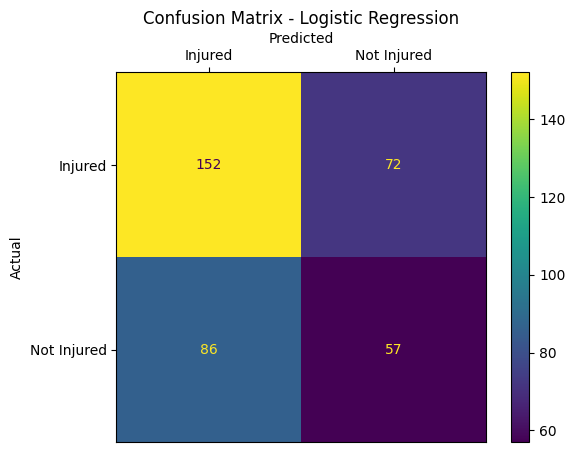

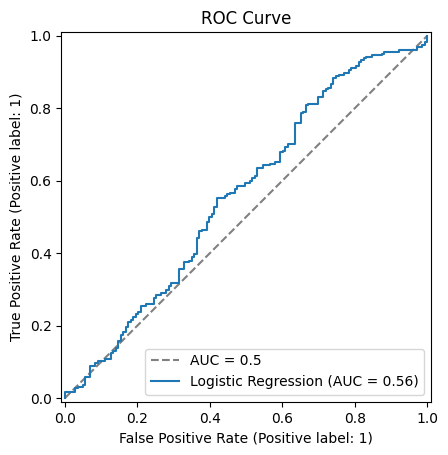

<Figure size 640x480 with 0 Axes>

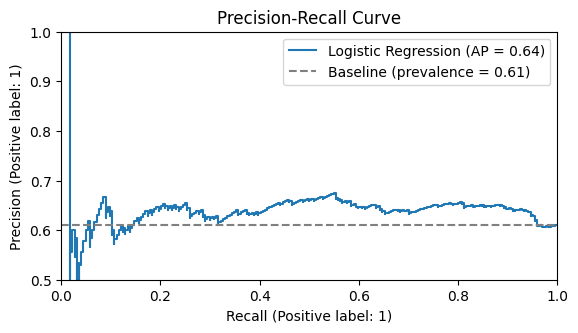

<Figure size 640x480 with 0 Axes>

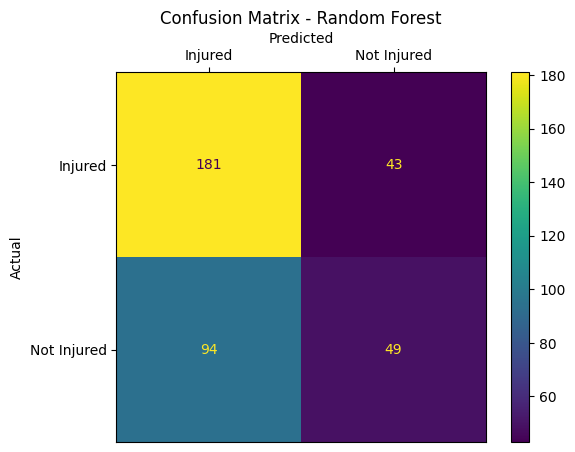

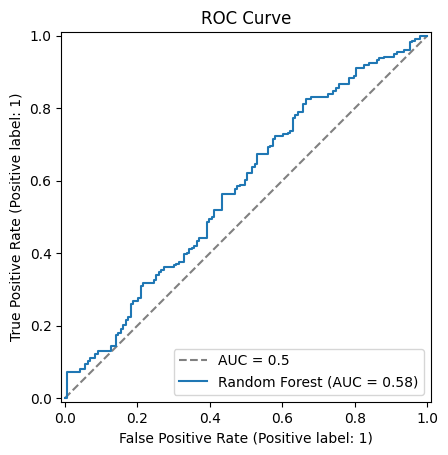

<Figure size 640x480 with 0 Axes>

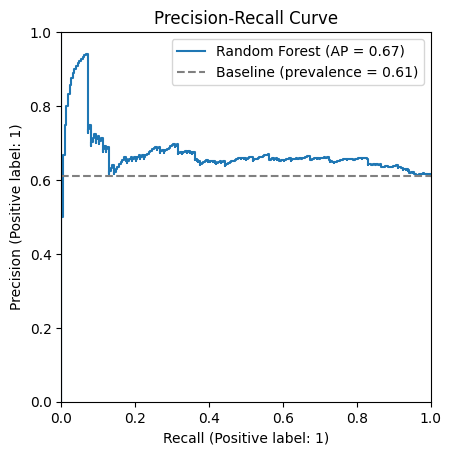

<Figure size 640x480 with 0 Axes>

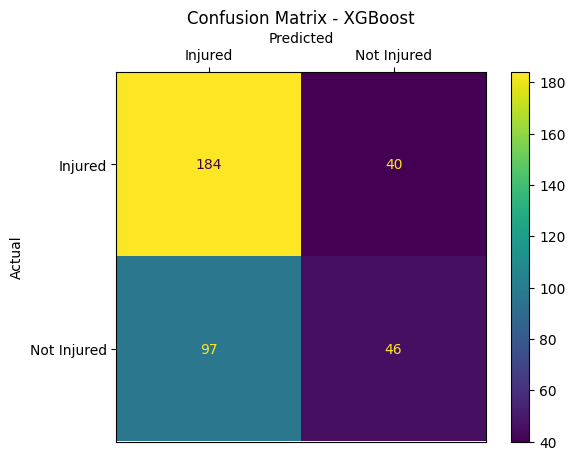

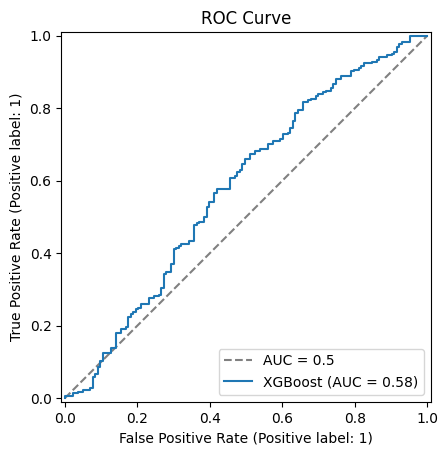

<Figure size 640x480 with 0 Axes>

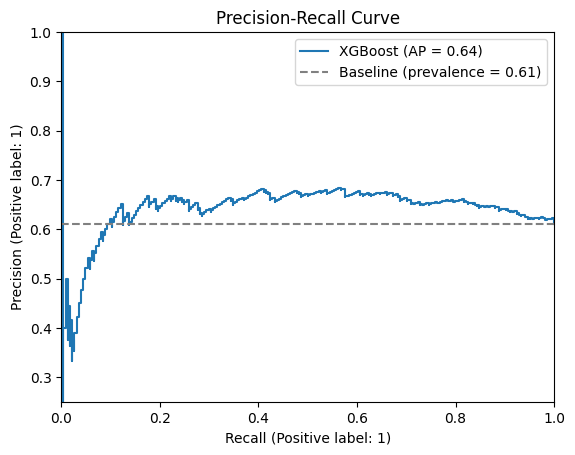

<Figure size 640x480 with 0 Axes>

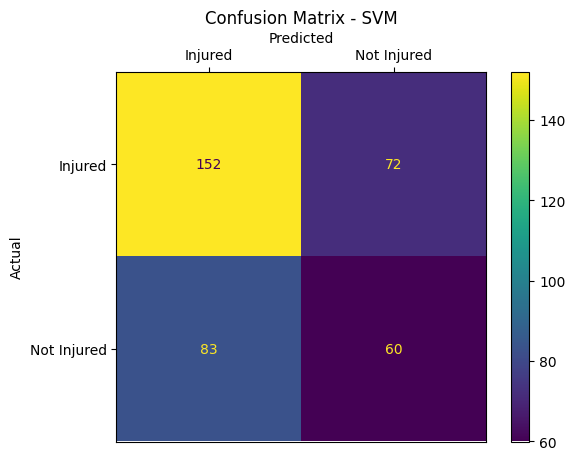

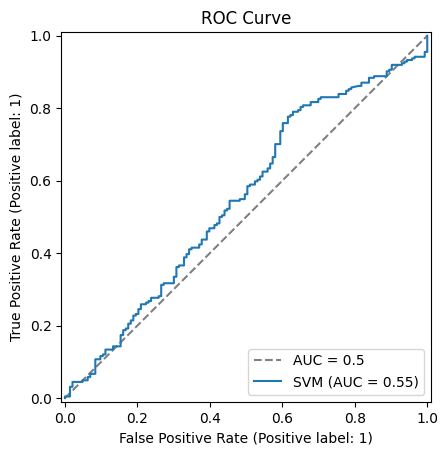

<Figure size 640x480 with 0 Axes>

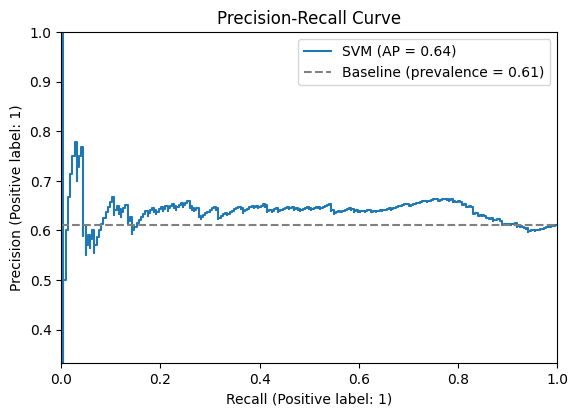

In [8]:
X_test = pd.read_csv(c.RICKD_MODEL_1_X_TEST_FILE_40_FEATURES_2, index_col=0)
y_test = pd.read_csv(c.RICKD_MODEL_1_Y_TEST_FILE_2, index_col=0)

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


for model_name, model in trained_models.items():
    print('\n' + '='*30)
    print(f"Training {model_name}...")
    print('='*30)

    # Find the best threshold from the validation set
    y_pred_proba_val = model.predict_proba(X_val)[:, 1]  # Keep only the probability of the positive class
    best_threshold, stats = pick_threshold(y_val, y_pred_proba_val, method="macro")
    print(f"Best threshold: {best_threshold}")
    for k, v in stats.items():
        print(f"Best {k}: {v}")

    pred = SklearnAPIPredictor(model)
    test_summary = model_test_summary(model, X_test, y_test, threshold=best_threshold,
        predictor=pred, model_name=model_name, save_predictions=True)
    
    results[model_name].update(test_summary)

Model Performance Comparison by Test ROC AUC:
                 Model  Test ROC AUC  Test PR AUC  Test Accuracy  \
2              XGBoost        0.5803       0.6428         0.6267   
1        Random Forest        0.5780       0.6712         0.6267   
0  Logistic Regression        0.5614       0.6444         0.5695   
3                  SVM        0.5500       0.6411         0.5777   

   Test Precision  Test Recall  Test F1-Score  Test Prevalence  Test Threshold  
2          0.6548       0.8214         0.5652           0.6104          0.6130  
1          0.6582       0.8080         0.5712           0.6104          0.5093  
0          0.6387       0.6786         0.5386           0.6104          0.4462  
3          0.6468       0.6786         0.5493           0.6104          0.6226  

Best performing model: XGBoost
Best Test ROC AUC Score: 0.5803


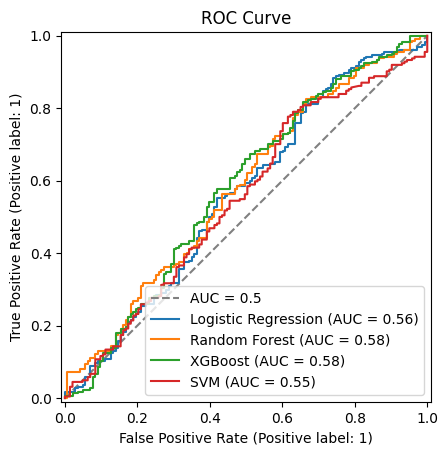

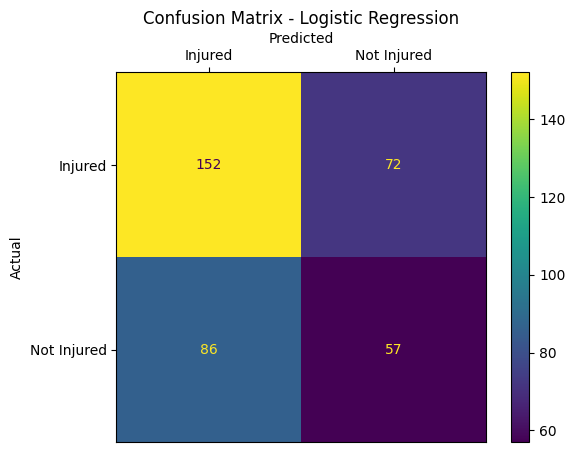

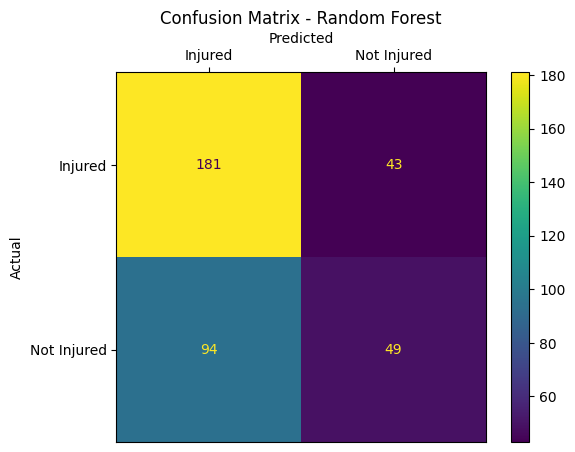

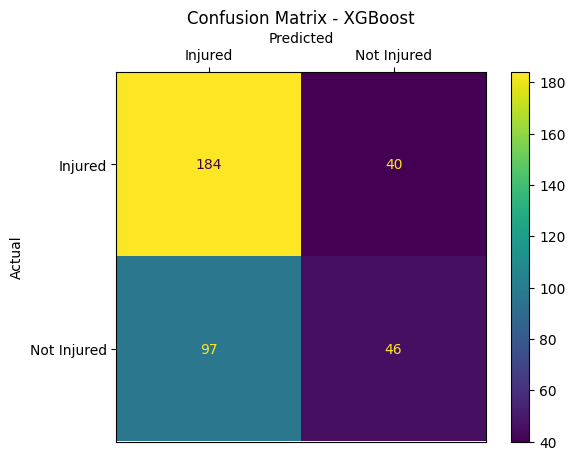

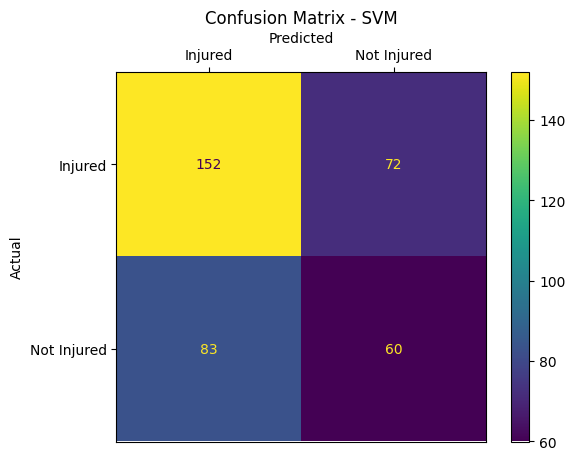

In [9]:
comparison_data = []
ax = plt.gca()

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='AUC = 0.5')

for model_name, result in results.items():
    comparison_data.append({
        'Model': model_name,
        'Test ROC AUC': result['auc_roc'],
        'Test PR AUC': result['auc_pr'],
        'Test Accuracy': result['accuracy'],
        'Test Precision': result['precision'],
        'Test Recall': result['recall'],
        'Test F1-Score': result['f1'],
        'Test Prevalence': result['prevalence'],
        'Test Threshold': result['threshold'],
    })
    roc_disp = RocCurveDisplay.from_predictions(
        y_test, 
        result['y_pred_proba'], 
        name=model_name,
        ax=ax,
    )
roc_disp.ax_.set_title('ROC Curve')

for model_name, result in results.items():
    class_labels = ['Injured', 'Not Injured']
    cm_disp = ConfusionMatrixDisplay.from_predictions(
        y_test, 
        result['y_pred'], 
        display_labels=class_labels,
        labels=[1, 0]
    )
    cm_disp.ax_.xaxis.set_label_position('top')
    cm_disp.ax_.xaxis.set_ticks_position('top')
    cm_disp.ax_.xaxis.set_label_text('Predicted')
    cm_disp.ax_.yaxis.set_label_text('Actual')
    cm_disp.ax_.set_title(f'Confusion Matrix - {model_name}')

PRIMARY_METRIC = 'Test ROC AUC'
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(PRIMARY_METRIC, ascending=False)

print(f"Model Performance Comparison by {PRIMARY_METRIC}:")
print('='*50)
print(comparison_df.round(4))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest performing model: {best_model_name}")
print(f"Best {PRIMARY_METRIC} Score: {comparison_df.iloc[0][PRIMARY_METRIC]:.4f}")

In [10]:
import pickle
from pathlib import Path

if SAVE_MODEL:
    folder_path = Path(f"{c.RICKD_MODELS_FOLDER}/{MODEL_NAME}")
    folder_path.mkdir(parents=True, exist_ok=True)

    with open(f"{folder_path}/results.pkl", "wb") as f:
        pickle.dump(results, f)